In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('../names.txt','r').read().splitlines()

In [4]:
## creating characters vocabulary
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y= [], []
    for w in words: 

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print("'.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch. tensor(X)
    Y = torch. tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random. seed(42)
random. shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])            ## 80% for training
Xdev, Ydev = build_dataset(words[n1:n2])        ## 10% for development/validation
Xte, Yte = build_dataset(words[n2:])            ## 10% for testing

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:

## Same code but more better structured 
n_embed = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed), generator=g)
emb = C[Xtr]
w1 = torch.randn((n_embed*block_size, n_hidden), generator=g) * 5/3 / (n_embed * block_size)**0.5 ## added gain to save the variance
# b1 = torch.randn(n_hidden, generator=g) * 0.1
w2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.1
gain = torch.ones((1,n_hidden))
shift = torch.zeros((1,n_hidden))
running_bnmean = torch.zeros((1,n_hidden))
running_bnstd = torch.ones((1,n_hidden))
parameters = [C,w1,b1,w2,b2,gain,shift]
length = sum(p.nelement() for p in parameters)
for p in parameters:
    p.requires_grad = True

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ w1  #+ b1  # hidden layer pre-activation
    # ----- batch normalization
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = gain * (hpreact - bnmeani) / bnstdi + shift

    with torch.no_grad():
        running_bnmean = 0.999 * running_bnmean + 0.001 * bnmeani
        running_bnstd = 0.999 * running_bnstd + 0.001 * bnstdi
    # ----- Non linearity
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ w2 + b2  # output layer (initial loss depens of w2 and b2 so lets update date)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #break ## we are chcking the first loss value and as we can see it is really high 27.881, now if all the characters should have a same probability of coming next then 
## initial loss should be 3.29 somthing as 1/27 so now we will try to decrease the initail loss

      0/ 200000: 3.3153
  10000/ 200000: 2.1967
  20000/ 200000: 2.3357
  30000/ 200000: 2.4398
  40000/ 200000: 2.0125
  50000/ 200000: 2.2543
  60000/ 200000: 2.4798
  70000/ 200000: 2.0892
  80000/ 200000: 2.2798
  90000/ 200000: 2.1797
 100000/ 200000: 1.9467
 110000/ 200000: 2.2905
 120000/ 200000: 1.9828
 130000/ 200000: 2.4419
 140000/ 200000: 2.3889
 150000/ 200000: 2.1927
 160000/ 200000: 1.9727
 170000/ 200000: 1.8598
 180000/ 200000: 1.9931
 190000/ 200000: 1.8311


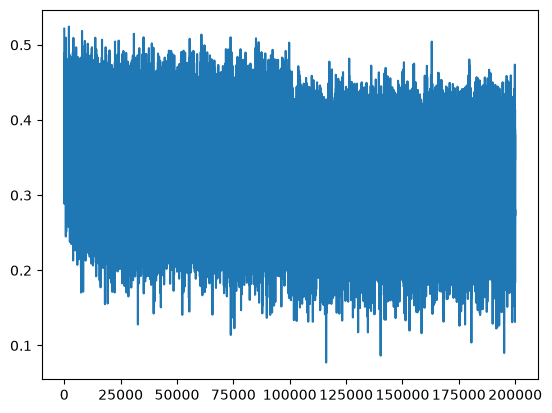

In [36]:
plt.plot(lossi)

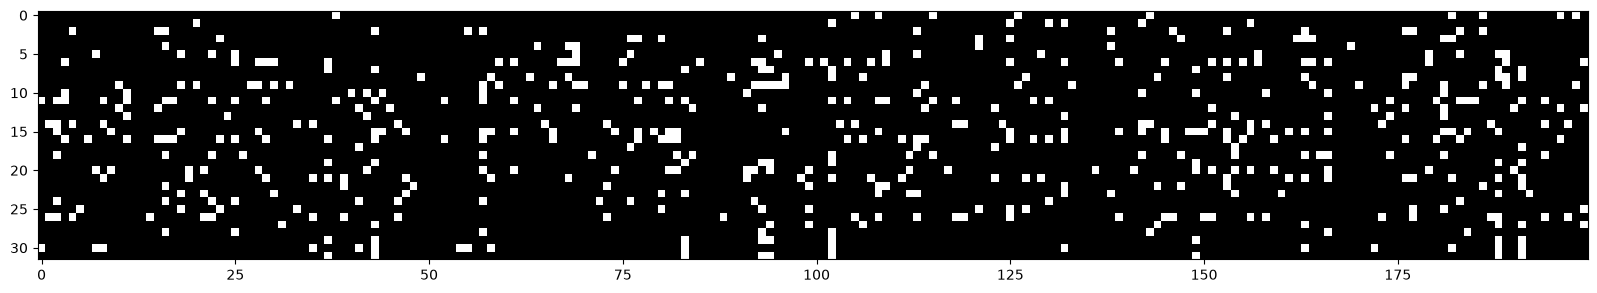

In [55]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

tensor(-0.0073) tensor(1.0024)
tensor(-0.0010) tensor(0.9734)


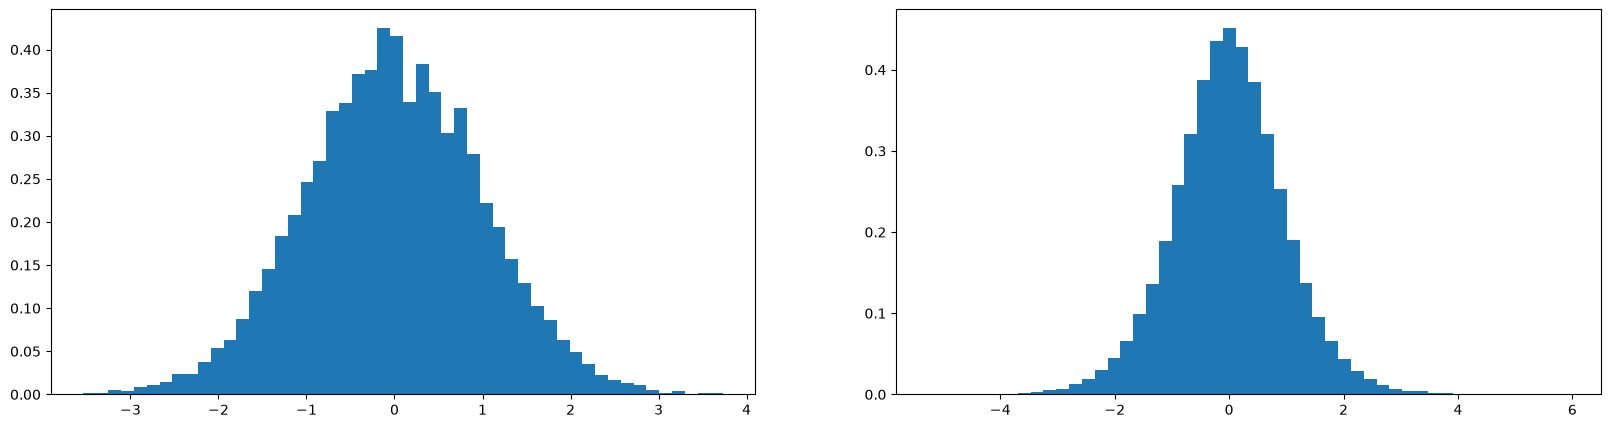

In [52]:
## 
x = torch.randn(1000,10)
w = torch.randn(10,200) / 10**0.5## To preserve the weights and stop the std from expanding is to just devide the w via sqrt(fn_in) where fn_in is number of inputs
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

# The mean of x and y remains close to 0, but the standard deviation of y is much larger. This means the distribution becomes wider after the matrix multiplication. If this keeps happening across layers, activations will grow larger and eventually saturate functions like tanh. Ideally, we want the output of each layer to maintain approximately the same distribution as its input—a zero mean and a standard deviation close to 1.

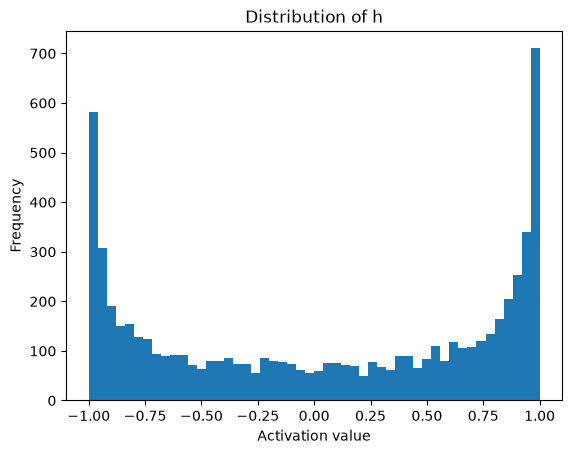

In [56]:
## Histogram of 'h'
plt.hist(h.view(-1).tolist(), bins=50)
plt.title("Distribution of h")
plt.xlabel("Activation value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(h.mean())
print(h.std())
val = abs(h) > 0.99
print(val)

tensor(0.0316, grad_fn=<MeanBackward0>)
tensor(0.9225, grad_fn=<StdBackward0>)
tensor([[False, False, False,  ...,  True,  True,  True],
        [False,  True,  True,  ..., False,  True, False],
        [ True,  True,  True,  ..., False, False, False],
        ...,
        [ True,  True,  True,  ..., False, False, False],
        [ True, False,  True,  ..., False,  True,  True],
        [ True,  True,  True,  ..., False, False, False]])


In [57]:
(abs(h) > 0.99).float().mean()

tensor(0.0853)

In [68]:
## calibrate the batch norm at the end of the training
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ w1 + b1
    ## measure the mean and std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [69]:
bnmean

tensor([[-2.4773,  0.6482, -0.9038,  1.2059,  1.0851,  1.1841,  1.8312, -2.2007,
          0.4209,  1.5280, -1.4624, -2.8243, -0.5219,  0.1129, -0.0071, -1.1469,
          0.6576, -2.6866, -0.1322,  1.7455, -0.8081, -0.2384,  0.1404,  0.6395,
          1.2271,  0.4512,  2.1681,  0.5914,  0.9018,  1.7080, -0.2960, -0.9093,
          0.0269, -0.6920, -0.4432, -1.1835,  0.1154,  0.3790, -0.4256,  1.1535,
         -0.3872, -1.3159, -0.1589, -0.4232,  0.7980,  0.6457,  2.1241, -0.9417,
          2.4109,  1.7687,  0.8622,  0.2509,  1.8046,  0.5077,  0.5303, -1.8816,
          0.0843,  0.5369,  1.4597, -0.7728, -0.5255,  1.0328,  0.5684,  0.5151,
          1.5887,  1.0950, -0.9374,  2.1152, -0.5519,  0.0164, -0.1246, -0.5937,
          1.0577, -1.1014, -2.9810,  0.5123,  1.4472, -0.1785,  0.0872,  0.5029,
          0.4183,  1.2750,  1.8850,  0.6818,  0.0661, -0.1000, -1.6675,  0.2507,
          2.1699, -0.0081, -0.4902,  1.4959, -0.7223, -1.2432, -0.9523,  0.1800,
          0.1811, -0.4476,  

In [70]:
running_bnmean

tensor([[-2.4963e+00,  6.5797e-01, -8.9071e-01,  1.2041e+00,  1.0874e+00,
          1.1764e+00,  1.8277e+00, -2.2138e+00,  4.0882e-01,  1.5071e+00,
         -1.4730e+00, -2.8285e+00, -5.3363e-01,  1.0346e-01,  2.5952e-04,
         -1.1291e+00,  6.6043e-01, -2.7065e+00, -1.5427e-01,  1.7368e+00,
         -8.1140e-01, -2.1908e-01,  1.3728e-01,  6.3832e-01,  1.2263e+00,
          4.5172e-01,  2.1722e+00,  5.8472e-01,  9.0196e-01,  1.7135e+00,
         -3.0739e-01, -9.1225e-01,  2.9601e-02, -6.9414e-01, -4.4583e-01,
         -1.1844e+00,  1.1846e-01,  3.6698e-01, -4.2238e-01,  1.1598e+00,
         -3.9479e-01, -1.3390e+00, -1.6178e-01, -4.1963e-01,  8.0163e-01,
          6.5443e-01,  2.1244e+00, -9.5670e-01,  2.4063e+00,  1.7575e+00,
          8.4862e-01,  2.4306e-01,  1.7943e+00,  5.0682e-01,  5.2240e-01,
         -1.8845e+00,  8.2615e-02,  5.3860e-01,  1.4765e+00, -7.7452e-01,
         -5.4250e-01,  1.0265e+00,  5.6063e-01,  5.1055e-01,  1.5882e+00,
          1.0804e+00, -9.4346e-01,  2.

In [71]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb. view(emb. shape[0], -1) # concat into (N, block_size *n_embd)
    hpreact = embcat @ w1 + b1  # hidden layer pre-activation
    hpreact = gain * (hpreact - running_bnmean) / running_bnstd + shift
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ w2 + b2 # (N, vocab_size)
    loss = F.cross_entropy (logits, y)
    print (split, loss. item())
split_loss('train')
split_loss('val')

train 2.0663647651672363
val 2.1048905849456787


# In the above code, we did bnmean and bnstd, so that we can get the prediction even for a single word instead of whole batch of words, because now mean and std is of whole dataset and it is fixed. But no one wants to do the same at the second stage of training so, now we will keep track of running statistics while doing training so we will have updated bnmean and bnstd to use.

## All loss after every tiny update 
# Initial Loss
Training Loss - 2.1267
Validation Loss - 2.1697

# After a quick fix to multiple 0.01 to the weight w2
Training Loss - 2.0695
Validation Loss - 2.1297

# After a quick fix via multiplying 0.1 to w1 we were to reduce the w1 and gets the less saturation for h
Training Loss - 2.0602
Validation Loss - 2.1129

# After applying kiamin init to preserve the variance
Training Loss - 2.0382
Validation Loss - 2.1060

# After applying batch normalization
Training Loss - 2.0665
Validation Loss - 2.1046



In [82]:
## summarizing everything by training deeper neural network
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, num_features,eps = 1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        ## Parameter trained in backpropagation
        self.gamma = torch.ones((1, num_features))
        self.beta = torch.zeros((1,num_features))
        ## Parameter used in buffer
        self.running_mean = torch.zeros((1, num_features))
        self.running_var = torch.ones((1,num_features))
        self.training=True
    def __call__(self,x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True) 
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            ## update buffer
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma , self.beta]
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []


In [83]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
n_embed = 10
n_hidden = 100

C = torch.randn((vocab_size, n_embed), generator = g)
layers = [Linear(n_embed*block_size, n_hidden), Tanh(),
Linear(n_hidden, n_hidden), Tanh(),
Linear(n_hidden, n_hidden), Tanh(),
Linear(n_hidden, n_hidden), Tanh(),
Linear(n_hidden, n_hidden), Tanh(),
Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    layers[-1].weight *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

46497


In [84]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        embcat = layer(embcat)
    loss = F.cross_entropy(embcat, Yb)  # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break ## we are chcking the first loss value and as we can see it is really high 27.881, now if all the characters should have a same probability of coming next then 
## initial loss should be 3.29 somthing as 1/27 so now we will try to decrease the initail loss

      0/ 200000: 3.2962


layer 1 (      Tanh): mean -0.02 | std 0.75 | saturated: 9.88 
layer 3 (      Tanh): mean -0.00 | std 0.69 | saturated: 3.38 
layer 5 (      Tanh): mean 0.00 | std 0.67 | saturated: 2.47 
layer 7 (      Tanh): mean -0.01 | std 0.66 | saturated: 1.44 
layer 9 (      Tanh): mean -0.02 | std 0.66 | saturated: 1.50 


Text(0.5, 1.0, 'Activation Function')

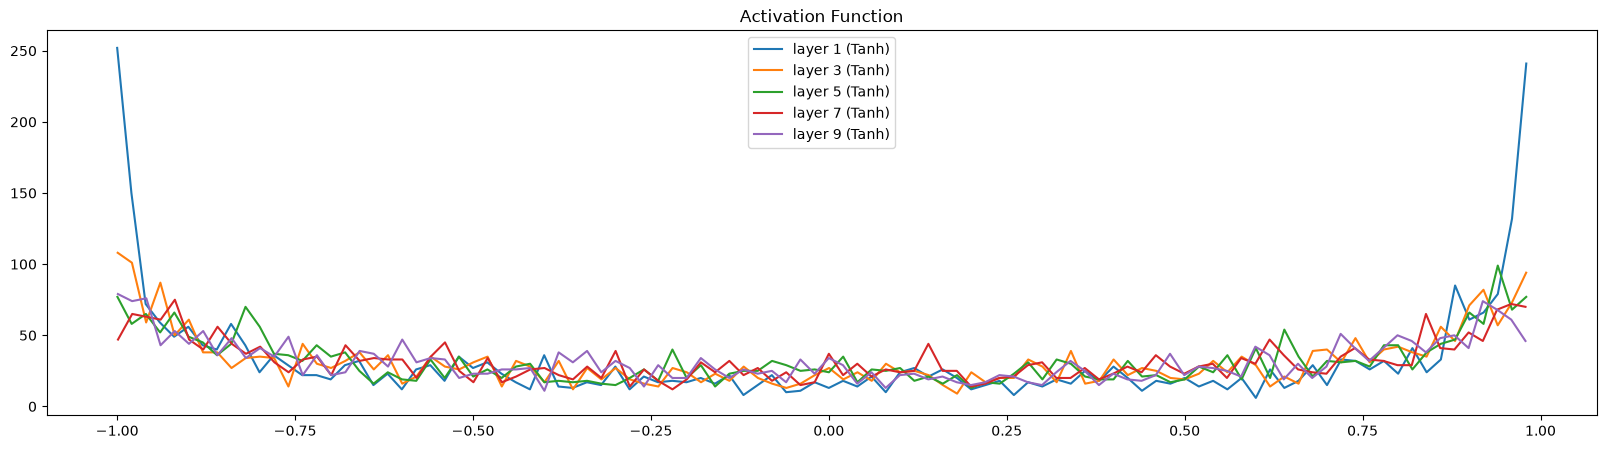

In [ ]:
## Tanh for output 
plt.figure(figsize=(20,5))
legends = [] # this is used to display proper naming for each layer
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print(f'layer %d (%10s): mean %.2f | std %.2f | saturated: %.2f ' % (i, layer.__class__.__name__, t.mean(), t.std() , (t.abs() > 0.99).float().mean()*100))
        ny, nx = torch.histogram(t)
        plt.plot(nx[:-1].detach(), ny.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Activation Function')

layer 1 (      Tanh): mean +0.000010 | std 4.205588e-04
layer 3 (      Tanh): mean -0.000003 | std 3.991179e-04
layer 5 (      Tanh): mean +0.000003 | std 3.743020e-04
layer 7 (      Tanh): mean +0.000015 | std 3.290473e-04
layer 9 (      Tanh): mean -0.000014 | std 3.054035e-04


Text(0.5, 1.0, 'Gradient Distribution')

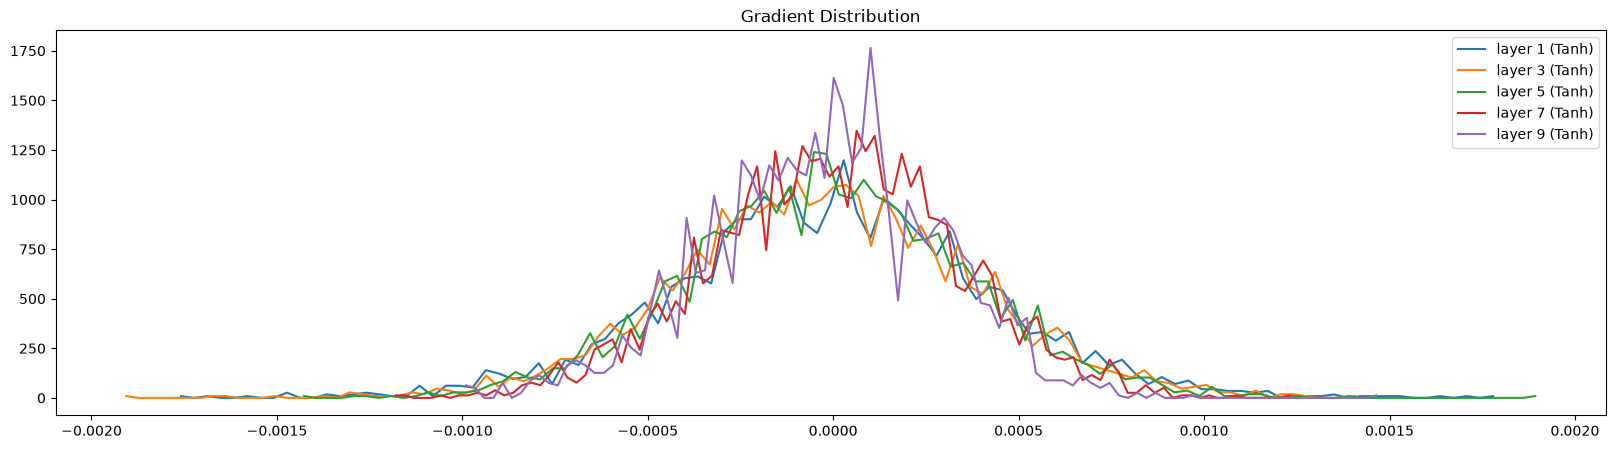

In [112]:
## Tanh for gradient
plt.figure(figsize=(20,5))
legends = [] # this is used to display proper naming for each layer
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(f'layer %d (%10s): mean %+f | std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        ny, nx = torch.histogram(t, density=True)
        plt.plot(nx[:-1].detach(), ny.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Gradient Distribution')